E-Commerce Sales Analysis Using numpy, Pandas and Matplotlib

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [40]:
# Load Dataset
df = pd.read_csv("ecommerce.csv")
df

,Product,Category,Price,Quantity,Month
0,Laptop,Electronics,50000,5,Aug
1,Mobile,Electronics,25000,8,Dec
2,Headphones,Accessories,2000,15,Nov
3,Keyboard,Accessories,1500,10,Oct
4,Mouse,Accessories,800,20,Apr
...,...,...,...,...,...
95,Smartwatch,Electronics,5350,8,Sep
96,Speaker,Accessories,3000,7,Oct
97,Tablet,Electronics,18000,4,Aug
98,Camera,Electronics,36000,3,Jan


In [41]:
# Display First 5 Rows
print("First 5 Records:")
print(df.head())

First 5 Records:
      Product     Category  Price  Quantity Month
0      Laptop  Electronics  50000         5   Aug
1      Mobile  Electronics  25000         8   Dec
2  Headphones  Accessories   2000        15   Nov
3    Keyboard  Accessories   1500        10   Oct
4       Mouse  Accessories    800        20   Apr


In [42]:
# Dataset Information
print("\nShape of Dataset:", df.shape)

print("\nColumns:")
print(df.columns)

print("\nData Types:")
print(df.dtypes)


Shape of Dataset: (100, 5)

Columns:
Index(['Product', 'Category', 'Price', 'Quantity', 'Month'], dtype='str')

Data Types:
Product       str
Category      str
Price       int64
Quantity    int64
Month         str
dtype: object


In [43]:
# Check null values
df.isnull().sum()

Product     0
Category    0
Price       0
Quantity    0
Month       0
dtype: int64

In [44]:
# Revenue Column
df["Revenue"] = df["Price"] * df["Quantity"]

print("\nDataset with Revenue:")
print(df.head())


Dataset with Revenue:
      Product     Category  Price  Quantity Month  Revenue
0      Laptop  Electronics  50000         5   Aug   250000
1      Mobile  Electronics  25000         8   Dec   200000
2  Headphones  Accessories   2000        15   Nov    30000
3    Keyboard  Accessories   1500        10   Oct    15000
4       Mouse  Accessories    800        20   Apr    16000


In [45]:
# Total revenue
total_revenue = np.sum(df["Revenue"])
print("Total Revenue =", total_revenue)

Total Revenue = 7387820


In [46]:
#Average Revenue
average_revenue = np.mean(df["Revenue"])
print("Average Revenue =", average_revenue)

Average Revenue = 73878.2


In [47]:
#Maximum and Minimum Revenue
print("Maximum Revenue =", np.max(df["Revenue"]))

print("Minimum Revenue =", np.min(df["Revenue"]))

Maximum Revenue = 309000
Minimum Revenue = 12600


In [48]:
#Product-wise Revenue
product_sales = df.groupby("Product")["Revenue"].sum()
product_sales

Product
Camera         962000
Headphones     308350
Keyboard       164940
Laptop        2502500
Mobile        1805900
Mouse          166110
Power Bank     162820
Smartwatch     396200
Speaker        200100
Tablet         718900
Name: Revenue, dtype: int64

In [49]:
#Category-wise Revenue
category_sales = df.groupby("Category")["Revenue"].sum()
category_sales

Category
Accessories    1002320
Electronics    6385500
Name: Revenue, dtype: int64

In [50]:
# TOP PRODUCTS
top_products = (
    df.groupby("Product")["Revenue"]
    .sum()
    .sort_values(ascending=False)
)
print("\nRevenue by Product:")
print(top_products)


Revenue by Product:
Product
Laptop        2502500
Mobile        1805900
Camera         962000
Tablet         718900
Smartwatch     396200
Headphones     308350
Speaker        200100
Mouse          166110
Keyboard       164940
Power Bank     162820
Name: Revenue, dtype: int64


In [51]:
#Top Revenue Product
top_product = product_sales.idxmax()

print("Top Revenue Product =", top_product)

Top Revenue Product = Laptop


Month
Jan     379180
Feb     327680
Mar     600270
Apr     441250
May     349000
Jun     240800
Jul     303630
Aug     699000
Sep     282900
Oct    1544760
Nov    1041430
Dec    1177920
Name: Revenue, dtype: int64


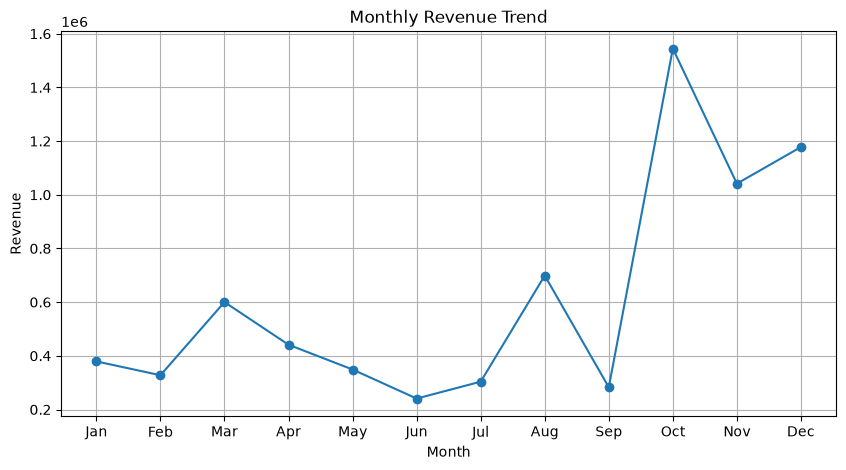

In [62]:
# LINE CHART
month_order = ["Jan","Feb","Mar","Apr","May","Jun",
               "Jul","Aug","Sep","Oct","Nov","Dec"]

monthly_sales = df.groupby("Month")["Revenue"].sum()

monthly_sales = monthly_sales.reindex(month_order)

print(monthly_sales)

plt.figure(figsize=(10,5))

plt.plot(monthly_sales.index,
         monthly_sales.values,
         marker="o")

plt.title("Monthly Revenue Trend")
plt.xlabel("Month")
plt.ylabel("Revenue")

plt.grid(True)

plt.show()

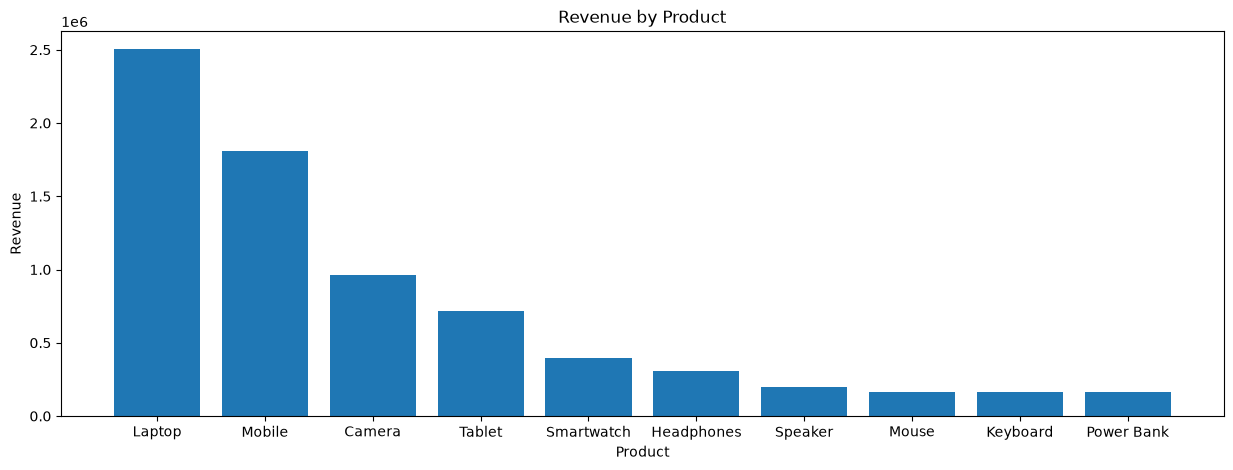

In [53]:
# BAR CHART
plt.figure(figsize=(15,5))
plt.bar(top_products.index, top_products.values)

plt.title("Revenue by Product")
plt.xlabel("Product")
plt.ylabel("Revenue")
plt.show()

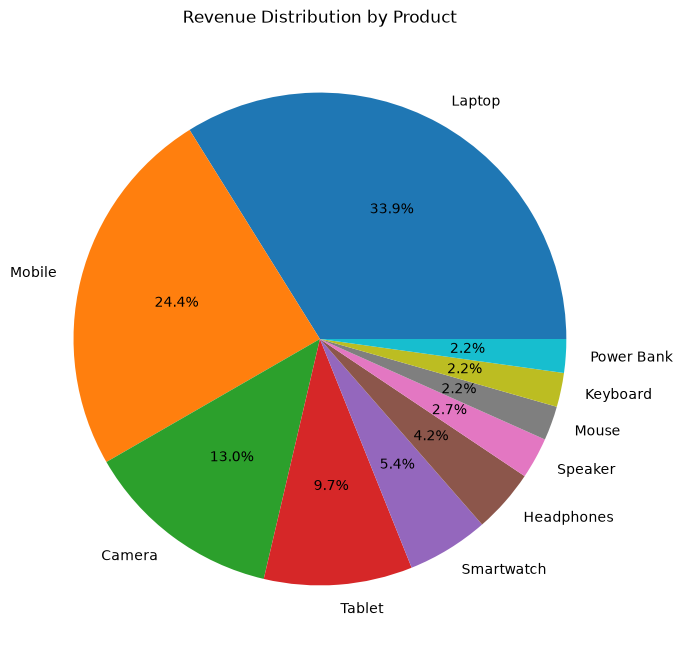

In [54]:
# PIE CHART
plt.figure(figsize=(8,8))
plt.pie(
    top_products.values,
    labels=top_products.index,              
    autopct="%1.1f%%"
)

plt.title("Revenue Distribution by Product")
plt.show()

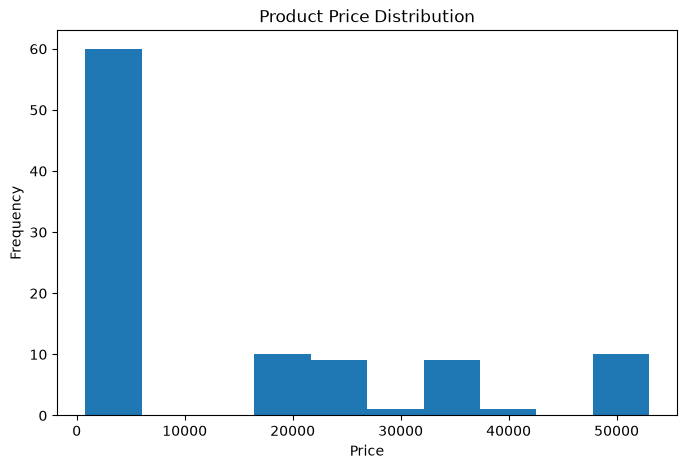

In [55]:
#Histogram
plt.figure(figsize=(8,5))

plt.hist(df["Price"])

plt.title("Product Price Distribution")
plt.xlabel("Price")
plt.ylabel("Frequency")

plt.show()

In [56]:
#Conclusion
print("Project Completed Successfully")

print("Total Revenue =", total_revenue)
print("Best Product =", top_product)

Project Completed Successfully
Total Revenue = 7387820
Best Product = Laptop
